# RipsNet
## User manual

RipsNet constructs a Tensorflow model for fast and robust estimation of persistent homology of
point clouds.

RipsNet is based on a *Deep Sets* architecture (cf. https://proceedings.neurips.cc/paper/2017/file/f22e4747da1aa27e363d86d40ff442fe-Paper.pdf), for details see the paper *RipsNet* (https://arxiv.org/abs/2202.01725).

### Example

This example instantiates a RipsNet model which can then be trained as any tensorflow model.

In [1]:
import gudhi_extra.tensorflow as getf
import tensorflow as tf
from tensorflow.keras import regularizers, layers

ragged_layers_size = [20, 10]
dense_layers_size = [10, 20]
output_units = 25
activation_fct = 'gelu'
output_activation = 'sigmoid'
dropout = 0
kernel_regularization = 0

ragged_layers = []
dense_layers = []

for n_units in ragged_layers_size:
    ragged_layers.append(getf.DenseRagged(units=n_units, use_bias=True, activation=activation_fct))

for n_units in dense_layers_size:
    dense_layers.append(layers.Dense(n_units, activation=activation_fct,
                                     kernel_regularizer=regularizers.l2(kernel_regularization)))
    dense_layers.append(layers.Dropout(dropout))

dense_layers.append(layers.Dense(output_units, activation=output_activation))

phi_1 = getf.TFBlock(ragged_layers)
perm_op = 'mean'  # can also be 'sum' (or a user specified function).
phi_2 = getf.TFBlock(dense_layers)
input_dim = 2

RN = getf.RipsNet(phi_1, phi_2, input_dim, perm_op=perm_op)

data_test = [[[-7.04493841, 9.60285858],
              [-13.14389003, -13.21854157],
              [-3.21137961, -1.28593644]],
             [[10.40324933, -0.80540584],
              [16.54752459, 0.70355361],
              [6.410207, -10.63175183],
              [2.96613799, -11.97463568]],
             [[4.85041719, -2.93820024],
              [2.15379915, -5.39669696],
              [5.83968556, -5.67350982],
              [5.25955172, -6.36860269]]]

tf_data_test = tf.ragged.constant(data_test, ragged_rank=1)

RN.predict(tf_data_test)

I0000 00:00:1785772061.753359   78424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785772061.753777   78424 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785772061.793911   78424 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785772062.742155   78424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step


array([[0.4399187 , 0.50409025, 0.53017807, 0.51139545, 0.48520982,
        0.46503642, 0.50179553, 0.48017347, 0.5426091 , 0.51707673,
        0.536787  , 0.47705865, 0.51837707, 0.54331297, 0.4993158 ,
        0.5332025 , 0.51808286, 0.5014576 , 0.53775775, 0.4750098 ,
        0.46883032, 0.488189  , 0.4960995 , 0.515088  , 0.530388  ],
       [0.44794708, 0.685315  , 0.45714223, 0.4122924 , 0.48475477,
        0.45669696, 0.59840864, 0.5900003 , 0.77165794, 0.43858513,
        0.44314137, 0.37490705, 0.78569365, 0.8397644 , 0.64148897,
        0.49055502, 0.5311279 , 0.6694529 , 0.4915492 , 0.38908997,
        0.48228654, 0.6080165 , 0.4788879 , 0.6062874 , 0.491377  ],
       [0.4593783 , 0.6316093 , 0.47585753, 0.43646392, 0.47555077,
        0.45962918, 0.579869  , 0.5564389 , 0.7131634 , 0.46597785,
        0.47000444, 0.40018746, 0.7192588 , 0.7718915 , 0.60161567,
        0.5002542 , 0.5154964 , 0.626783  , 0.49447486, 0.4147489 ,
        0.4781342 , 0.57890224, 0.4887556 , 0.

Once `RN` is properly trained it can be used to make predictions.
In this example RipsNet estimates persistence vectorizations (of output size 25) of a list of 3 point clouds of 3 points each) in 2D.

It yields an output of shape `nb_input_pointclouds x output_units`.
The `ragged_layers_size` and `dense_layers_size` define the architecture of the network.
To reach best performance, they should be tuned depending on the dataset.

## Tutorial

In this tutorial, we show how to use RipsNet to learn the topology of very simple synthetic data sets comprised of (noisy) circles. Let's first define the seed (for reproducibility), the number of point clouds that we will use for training RipsNet, the number of point clouds we will use to test it, the cardinality of the point clouds and finally the amount of corrupted points (when noise is added).

In [2]:
N_sets_train = 900  # Number of train point clouds
N_sets_test  = 300  # Number of test  point clouds
N_points     = 600  # Point cloud cardinality
N_noise      = 200  # Number of corrupted points

Next we use helper functions to compute these point clouds.

In [3]:
from utils.utils_ripsnet import create_multiple_circles

In [4]:
data_train,      label_train       = create_multiple_circles(N_sets_train, N_points, noisy=0, N_noise=N_noise)
clean_data_test, clean_label_test  = create_multiple_circles(N_sets_test,  N_points, noisy=0, N_noise=N_noise)
noisy_data_test, noisy_label_test  = create_multiple_circles(N_sets_test,  N_points, noisy=1, N_noise=N_noise)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 234.86it/s]


Let's check some of these point clouds!

In [5]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

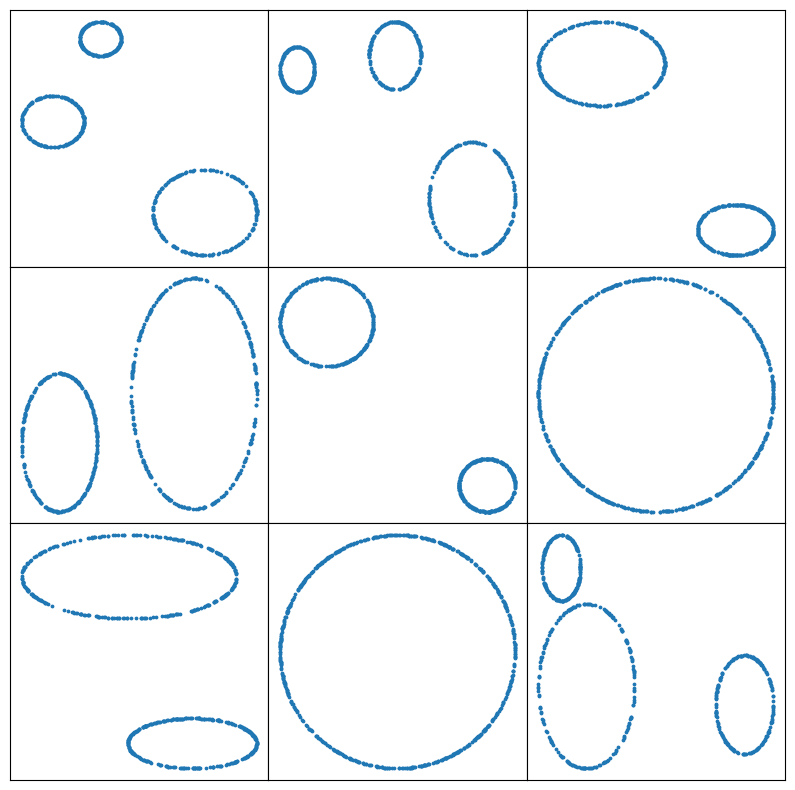

In [6]:
fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.scatter(clean_data_test[3*i+j][:,0], clean_data_test[3*i+j][:,1], s=3)
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_gudhi_pc.png', bbox_inches='tight')

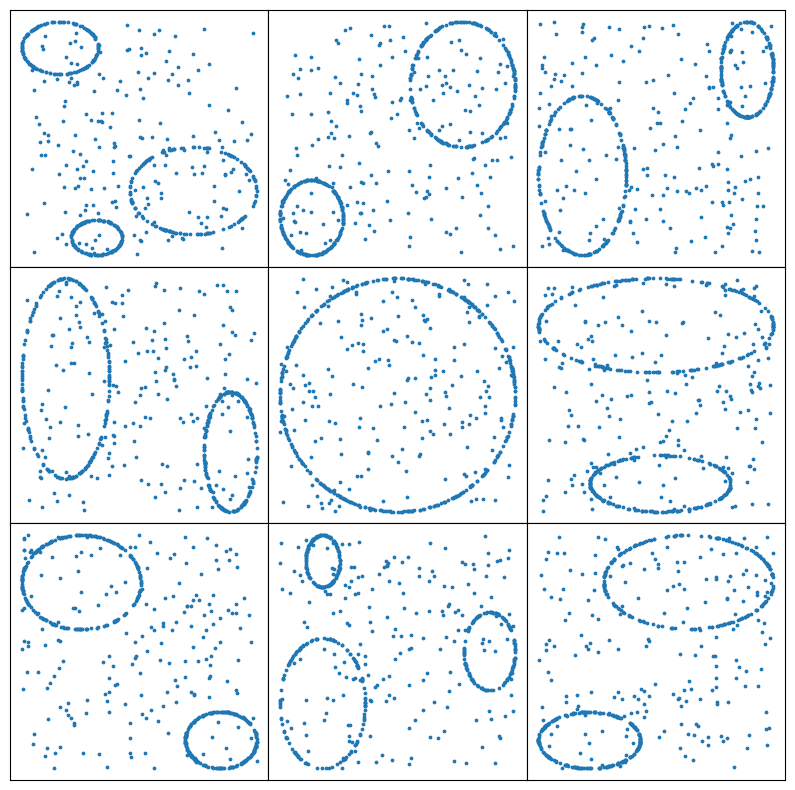

In [7]:
fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.scatter(noisy_data_test[3*i+j][:,0], noisy_data_test[3*i+j][:,1], s=3)
        plt.xticks([])
        plt.yticks([])
plt.savefig('noisy_gudhi_pc.png', bbox_inches='tight')

As one can see, they contain 1 to 3 circular shapes. We will use these circle numbers later for checking the accuracy of the topology computed by RipsNet. For now, let's save them as proper labels.

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder().fit(label_train)
label_classif_train = le.transform(label_train)
clean_label_classif_test  = le.transform(clean_label_test)
noisy_label_classif_test  = le.transform(noisy_label_test)

In order to train RipsNet, we need the correct topology on the train data. So let's compute it with [Gudhi](https://gudhi.inria.fr/python/latest/). The topology of point clouds can be inferred from several filtrations, so we will use a fast and sparse one (in 2D), namely the [Alpha filtration](https://gudhi.inria.fr/python/latest/alpha_complex_user.html). First, we need to get a sense of the maximal filtration value to use, which we will approximate with the largest pairwise distance of the first 30 point clouds.

In [10]:
import numpy as np
from sklearn.metrics import pairwise_distances

In [11]:
ds = [pairwise_distances(X).flatten() for X in data_train[:30]]
maxd = np.max(np.concatenate(ds))

Now, we can compute the persistence diagrams (in homology dimension 1) of the train, clean test and noisy test point clouds!

In [12]:
from tqdm import tqdm
import gudhi as gd

In [13]:
PD_train = []
for X in tqdm(data_train):
    st = gd.AlphaComplex(points=X).create_simplex_tree(max_alpha_square=maxd)
    st.persistence()
    dg = st.persistence_intervals_in_dimension(1)
    if len(dg) == 0:
        dg = np.empty([0,2])
    PD_train.append(dg)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 900/900 [00:06<00:00, 136.24it/s]


In [14]:
clean_PD_test = []
for X in tqdm(clean_data_test):
    st = gd.AlphaComplex(points=X).create_simplex_tree(max_alpha_square=maxd)
    st.persistence()
    dg = st.persistence_intervals_in_dimension(1)
    if len(dg) == 0:
        dg = np.empty([0,2])
    clean_PD_test.append(dg)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:02<00:00, 134.45it/s]


In [15]:
noisy_PD_test = []
for X in tqdm(noisy_data_test):
    st = gd.AlphaComplex(points=X).create_simplex_tree(max_alpha_square=maxd)
    st.persistence()
    dg = st.persistence_intervals_in_dimension(1)
    if len(dg) == 0:
        dg = np.empty([0,2])
    noisy_PD_test.append(dg)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:01<00:00, 270.19it/s]


RipsNet actually works on vectorizations of persistence diagrams (PDs), so we will try two: the [persistence image](https://jmlr.org/papers/volume18/16-337/16-337.pdf), and the [persistence landscape](https://jmlr.csail.mit.edu/papers/volume16/bubenik15a/bubenik15a.pdf). First, let's filter out any PD point with infinite coordinates.

In [16]:
from gudhi.representations import DiagramSelector

In [17]:
PVs_train, clean_PVs_test, noisy_PVs_test, PVs_params = [], [], [], []
pds_train      = DiagramSelector(use=True).fit_transform(PD_train)
clean_pds_test = DiagramSelector(use=True).fit_transform(clean_PD_test)
noisy_pds_test = DiagramSelector(use=True).fit_transform(noisy_PD_test)

Fortunately, Gudhi also has code for computing vectorizations!! However, before launching the computations, we have to estimate a few parameters: the image bandwidth (taken as the 20% quantile of the positive birth-persistence-transformed-PD pairwise distances),
and the image and landscape limits (taken as the min and max of birth-persistence-transformed-PD point coordinates). 

In [18]:
vpdtr = np.vstack(pds_train)
pers = vpdtr[:,1]-vpdtr[:,0]
bps_pairs = pairwise_distances(np.hstack([vpdtr[:,0:1],vpdtr[:,1:2]-vpdtr[:,0:1]])[:200]).flatten()
ppers = bps_pairs[np.argwhere(bps_pairs > 1e-5).ravel()]
sigma = np.quantile(ppers, .2)
im_bnds = [np.quantile(vpdtr[:,0],0.), np.quantile(vpdtr[:,0],1.), np.quantile(pers,0.), np.quantile(pers,1.)]
sp_bnds = [np.quantile(vpdtr[:,0],0.), np.quantile(vpdtr[:,1],1.)]

We can now compute and normalize the vectorizations (this can help RipsNet training)!

In [19]:
from gudhi.representations import Landscape, PersistenceImage

In [20]:
PI_params = {'bandwidth': sigma, 'weight': lambda x: 10*np.tanh(x[1]), 
             'resolution': [50,50], 'im_range': im_bnds}
PI_train = PersistenceImage(**PI_params).transform(pds_train)
clean_PI_test = PersistenceImage(**PI_params).transform(clean_pds_test)
noisy_PI_test = PersistenceImage(**PI_params).transform(noisy_pds_test)
MPI = np.max(PI_train)
PI_train /= MPI
clean_PI_test /= MPI
noisy_PI_test /= MPI

AttributeError: 'PersistenceImage' object has no attribute 'im_range_fixed_'

In [ ]:
PL_params = {'num_landscapes': 5, 'resolution': 300, 'sample_range': sp_bnds}
PL_train = Landscape(**PL_params).transform(pds_train)
clean_PL_test = Landscape(**PL_params).transform(clean_pds_test)
noisy_PL_test = Landscape(**PL_params).transform(noisy_pds_test)
MPL = np.max(PL_train)
PL_train /= MPL
clean_PL_test /= MPL
noisy_PL_test /= MPL

It is finally time to train RipsNet! We will do it with TensorFlow, and custom DeepSet operations.

In [ ]:
import tensorflow as tf
import gudhi_extra.tensorflow as getf

First, let's convert the point clouds into ragged tensors.

In [ ]:
tf_data_train = tf.ragged.constant([
    [list(c) for c in list(data_train[i])] for i in range(len(data_train))], ragged_rank=1)
tf_clean_data_test = tf.ragged.constant([
    [list(c) for c in list(clean_data_test[i])] for i in range(len(clean_data_test))], ragged_rank=1)
tf_noisy_data_test = tf.ragged.constant([
    [list(c) for c in list(noisy_data_test[i])] for i in range(len(noisy_data_test))], ragged_rank=1)

Next, we define our RipsNet architecture for learning persistence images, a sequence of fully-connected DeepSet layers, with GeLU activations, Adamax optimizer, and early stopping.

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-5, 
                                            patience=200, verbose=0, mode='auto', baseline=None, 
                                            restore_best_weights=False)
optim = tf.keras.optimizers.Adamax(learning_rate=5e-4)
inputs = tf.keras.Input(shape=(None,2), dtype ="float32", ragged=True)

In [ ]:
ragged_layers_size = [30,20,10]
dense_layers_size = [50,100,200]
output_units = PI_train.shape[1]
activation_fct = 'gelu'
output_activation = 'sigmoid'
initializer = None

In [ ]:
ragged_layers = []
dense_layers = []
for n_units in ragged_layers_size:
    ragged_layers.append(getf.DenseRagged(units=n_units, use_bias=True, activation=activation_fct,
                                     kernel_initializer=initializer, bias_initializer=initializer))

for n_units in dense_layers_size:
    dense_layers.append(tf.keras.layers.Dense(n_units, activation=activation_fct,
                                              kernel_initializer=initializer, bias_initializer=initializer))

dense_layers.append(tf.keras.layers.Dense(output_units, activation=output_activation,
                                          kernel_initializer=initializer, bias_initializer=initializer))

In [ ]:
phi_1 = getf.TFBlock(ragged_layers)
perm_op = 'mean'
phi_2 = getf.TFBlock(dense_layers)
input_dim = 2

model_PI = getf.RipsNet(phi_1, phi_2, input_dim, perm_op=perm_op)
model_PI.compile(optimizer=optim, loss="mse")

Time to learn!

In [ ]:
history = model_PI.fit(tf_data_train, PI_train, epochs=250, 
                       validation_data=(tf_clean_data_test, clean_PI_test), callbacks=[callback], verbose=0)

Learning is done! The advantage of RipsNet is that we can now use it to predict persistence images directly from point clouds in the blink of an eye!

In [ ]:
train_PI_prediction = model_PI.predict(tf_data_train)
clean_PI_prediction = model_PI.predict(tf_clean_data_test)
noisy_PI_prediction = model_PI.predict(tf_noisy_data_test)

Let's see how accurate the predictions of RipsNet really are, at least on the train set.

In [ ]:
fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.scatter(tf_clean_data_test[3*i+j,:,0], tf_clean_data_test[3*i+j,:,1], s=3)
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_gudhi_pc.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.imshow(np.flip(np.reshape(clean_PI_test[3*i+j], [50,50]), 0), cmap='jet')
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_gudhi_pi.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.imshow(np.flip(np.reshape(clean_PI_prediction[3*i+j], [50,50]), 0), cmap='jet')
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_ripsnet_pi.png', bbox_inches='tight')

Pretty good actually! Let's look at the test set now.

In [ ]:
fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.scatter(tf_noisy_data_test[3*i+j,:,0], tf_noisy_data_test[3*i+j,:,1], s=3)
        plt.xticks([])
        plt.yticks([])
plt.savefig('noisy_gudhi_pc.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.imshow(np.flip(np.reshape(noisy_PI_test[3*i+j], [50,50]), 0), cmap='jet')
        plt.xticks([])
        plt.yticks([])
        #plt.colorbar()
plt.savefig('noisy_gudhi_pi.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.imshow(np.flip(np.reshape(noisy_PI_prediction[3*i+j], [50,50]), 0), cmap='jet')
        plt.xticks([])
        plt.yticks([])
        #plt.colorbar()
plt.savefig('noisy_ripsnet_pi.png', bbox_inches='tight')

Yep, even though Gudhi now produces bad images because of the ambiant noise, RipsNet predictions still look rather good. Another way to quantify this is to see the difference between classifiers predicting the number of circles that are trained either from Gudhi or from RipsNet predictions. Let's first see how an XGBoost model performs when using Gudhi descriptors.

In [ ]:
from xgboost import XGBClassifier

In [ ]:
model_classif_gudhi = XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model_classif_gudhi.fit(PI_train, label_classif_train)
clean_test_acc_gudhi = model_classif_gudhi.score(clean_PI_test, clean_label_classif_test)
noisy_test_acc_gudhi = model_classif_gudhi.score(noisy_PI_test, noisy_label_classif_test)

In [ ]:
print("Accuracy on clean test set = " + str(clean_test_acc_gudhi))
print("Accuracy on noisy test set = " + str(noisy_test_acc_gudhi))

Well, the classifier definitely does well on clean data but struggles on noisy data. Let's see how another classifier trained on RipsNet descriptors now performs.

In [ ]:
model_classif_RN = XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model_classif_RN.fit(train_PI_prediction, label_classif_train)
clean_test_acc_RN = model_classif_RN.score(clean_PI_prediction, clean_label_classif_test)
noisy_test_acc_RN = model_classif_RN.score(noisy_PI_prediction, noisy_label_classif_test)

In [ ]:
print("Accuracy on clean test set = " + str(clean_test_acc_RN))
print("Accuracy on noisy test set = " + str(noisy_test_acc_RN))

Well, even though the accuracy is slightly worse on clean data, it does remarkably well when noise is added! This illustrates the robustness of RipsNet-based topological descriptors.

Now, let's play the same game with persistence landscapes, using the same architecture (except for the dimension of the final layer of course). In the three following cells, we define RipsNet, train it on landscapes, and use it to predict persistence landscapes from the data.

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-5, 
                                            patience=200, verbose=0, mode='auto', baseline=None, 
                                            restore_best_weights=False)
optim = tf.keras.optimizers.Adamax(learning_rate=5e-4)
inputs = tf.keras.Input(shape=(None,2), dtype ="float32", ragged=True)

In [ ]:
output_units = PL_train.shape[1]

dense_layers[-1] = tf.keras.layers.Dense(output_units, activation=output_activation,
                                          kernel_initializer=initializer, bias_initializer=initializer)

phi_1 = getf.TFBlock(ragged_layers)
perm_op = 'mean'
phi_2 = getf.TFBlock(dense_layers)
input_dim = 2

model_PL = getf.RipsNet(phi_1, phi_2, input_dim, perm_op=perm_op)
model_PL.compile(optimizer=optim, loss="mse")

In [ ]:
history = model_PL.fit(tf_data_train, PL_train, epochs=250, 
                       validation_data=(tf_clean_data_test, clean_PL_test), callbacks=[callback], verbose=0)

In [ ]:
train_PL_prediction = model_PL.predict(tf_data_train)
clean_PL_prediction = model_PL.predict(tf_clean_data_test)
noisy_PL_prediction = model_PL.predict(tf_noisy_data_test)

Let's see how good RipsNet is for landscapes now.

In [ ]:
fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.scatter(tf_clean_data_test[3*i+j,:,0], tf_clean_data_test[3*i+j,:,1], s=3)
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_gudhi_pc.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        for lidx in range(5):
            plt.plot(clean_PL_test[i][lidx*300:(lidx+1)*300]) 
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_gudhi_pl.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        for lidx in range(5):
            plt.plot(clean_PL_prediction[i][lidx*300:(lidx+1)*300])
        plt.xticks([])
        plt.yticks([])
plt.savefig('clean_ripsnet_pl.png', bbox_inches='tight')

In [ ]:
fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        ax.scatter(tf_noisy_data_test[3*i+j,:,0], tf_noisy_data_test[3*i+j,:,1], s=3)
        plt.xticks([])
        plt.yticks([])
plt.savefig('noisy_gudhi_pc.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        for lidx in range(5):
            plt.plot(noisy_PL_test[i][lidx*300:(lidx+1)*300]) 
        plt.xticks([])
        plt.yticks([])
plt.savefig('noisy_gudhi_pl.png', bbox_inches='tight')

fig = plt.figure(figsize=(10, 10)) 
gs = gridspec.GridSpec(3, 3, width_ratios=[1,1,1], wspace=0.0, hspace=0.0)
for i in range(3):
    for j in range(3):
        ax = plt.subplot(gs[i,j])
        for lidx in range(5):
            plt.plot(noisy_PL_prediction[i][lidx*300:(lidx+1)*300])
        plt.xticks([])
        plt.yticks([])
plt.savefig('noisy_ripsnet_pl.png', bbox_inches='tight')

As before, we end by training XGBoost classifier on both Gudhi and RipsNet generated landscapes.

In [ ]:
model_classif_gudhi = XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model_classif_gudhi.fit(PL_train, label_classif_train)
clean_test_acc_gudhi = model_classif_gudhi.score(clean_PL_test,  clean_label_classif_test)
noisy_test_acc_gudhi = model_classif_gudhi.score(noisy_PL_test,  noisy_label_classif_test)

In [ ]:
print("Accuracy on clean test set = " + str(clean_test_acc_gudhi))
print("Accuracy on noisy test set = " + str(noisy_test_acc_gudhi))

In [ ]:
model_classif_RN = XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model_classif_RN.fit(train_PL_prediction, label_classif_train)
clean_test_acc_RN = model_classif_RN.score(clean_PL_prediction, clean_label_classif_test)
noisy_test_acc_RN = model_classif_RN.score(noisy_PL_prediction, noisy_label_classif_test)

In [ ]:
print("Accuracy on clean test set = " + str(clean_test_acc_RN))
print("Accuracy on noisy test set = " + str(noisy_test_acc_RN))

The difference is less clear than for persistence images, but present nonetheless! Again, RipsNet exhibits better  robustness properties than Gudhi on noise data, while being faster and almost as good on clean data.